In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

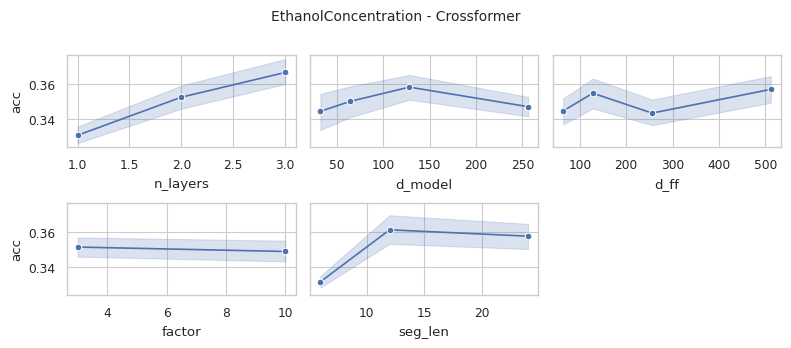

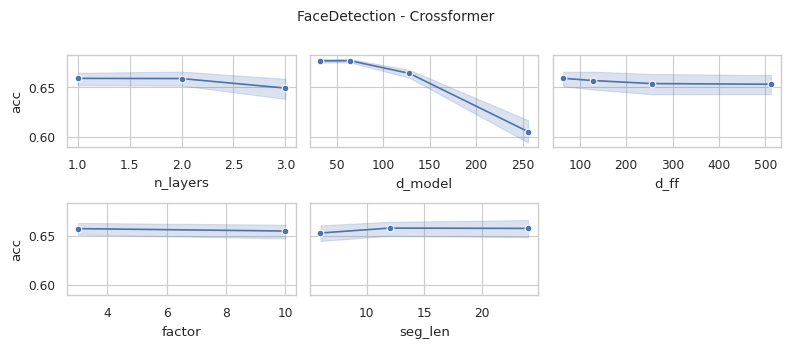

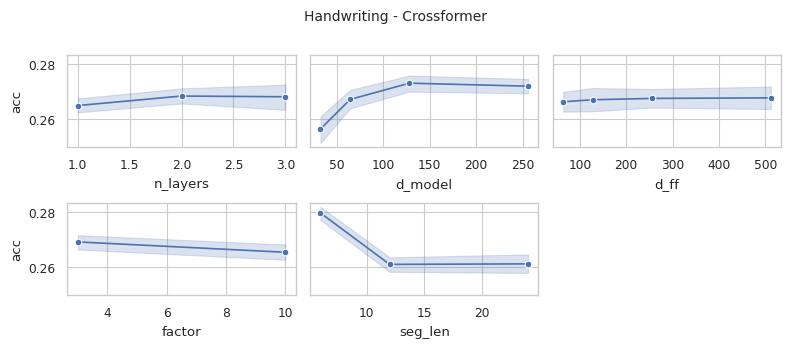

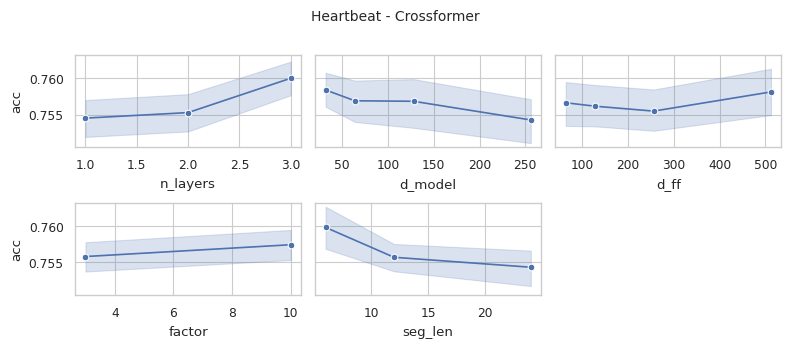

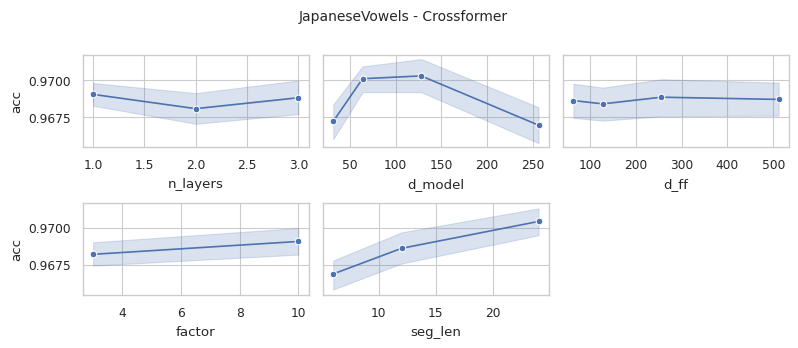

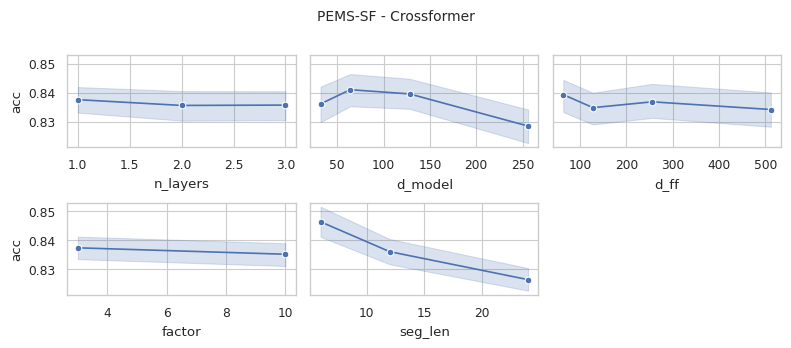

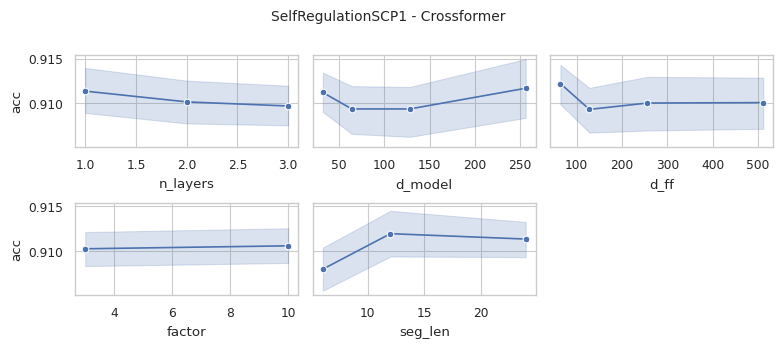

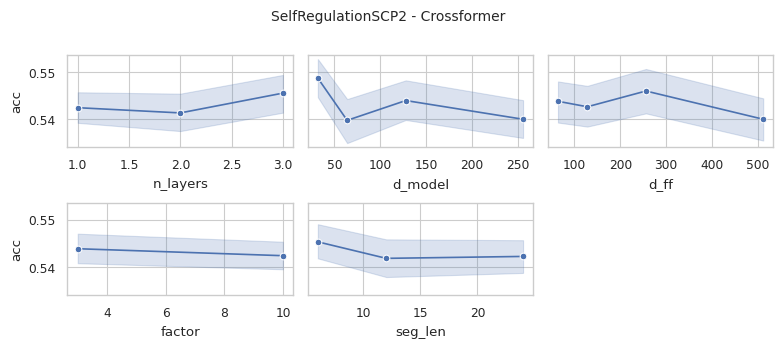

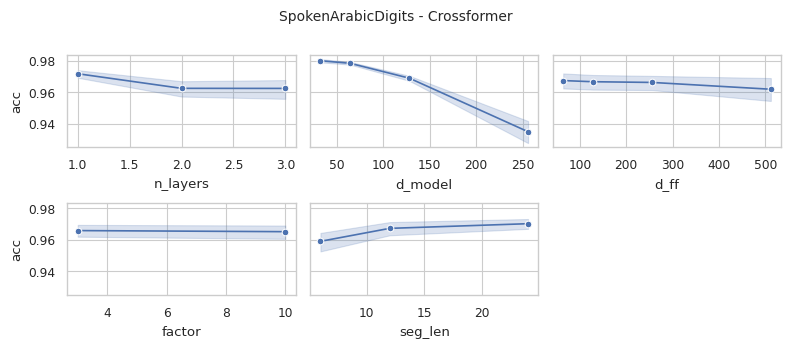

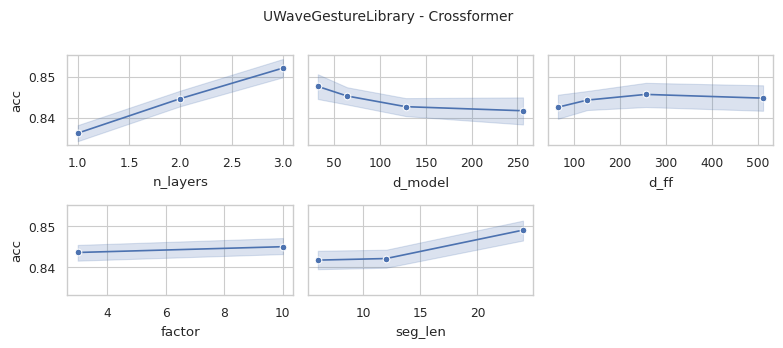

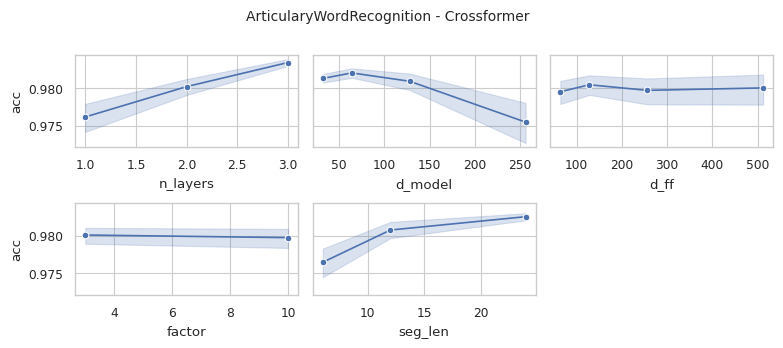

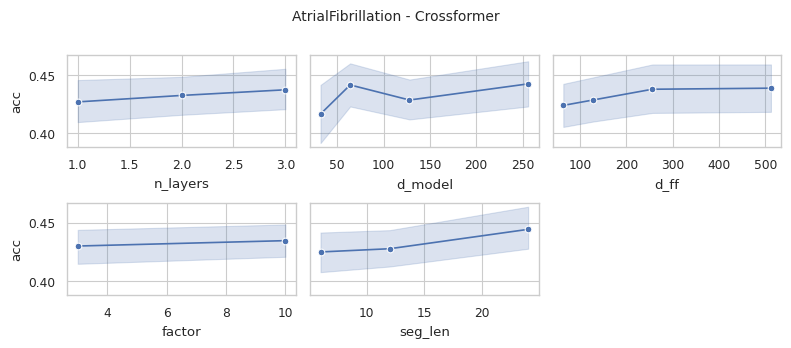

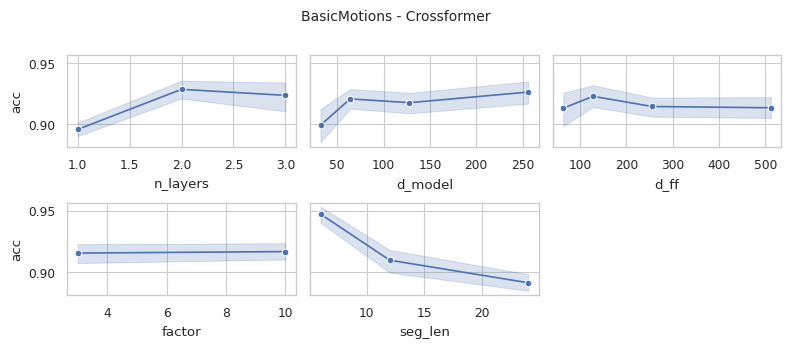

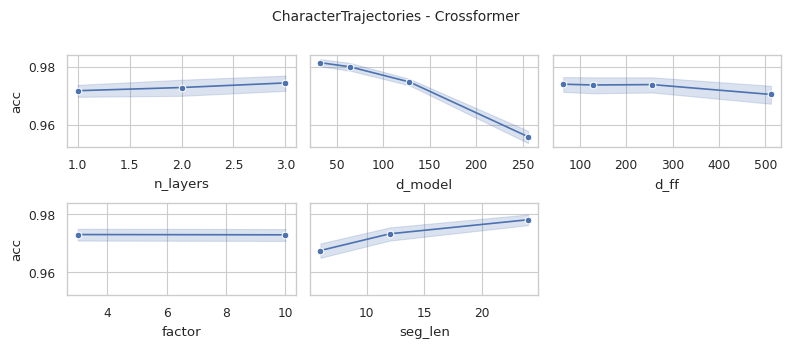

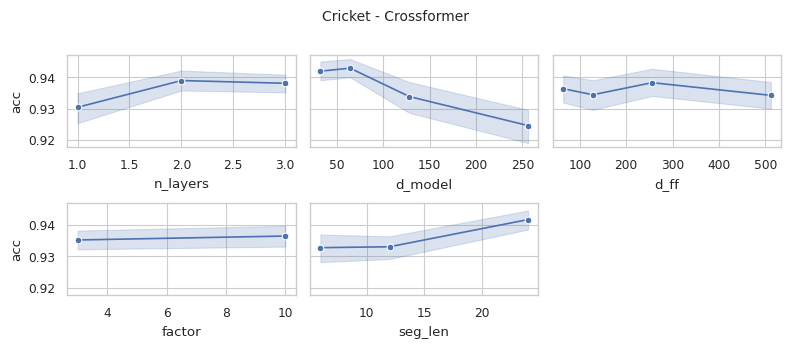

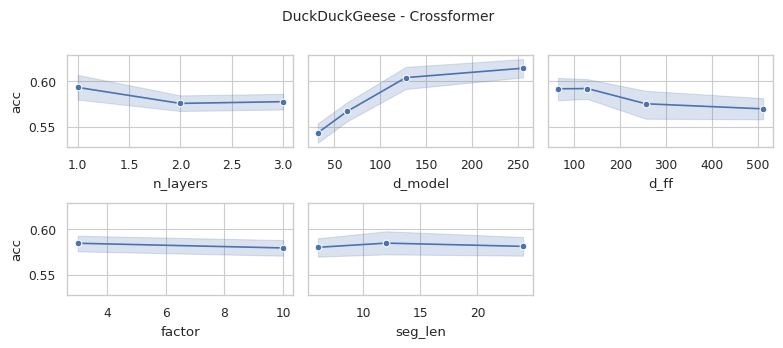

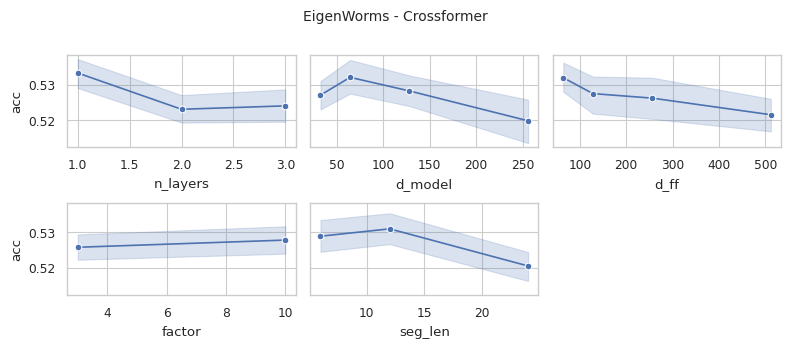

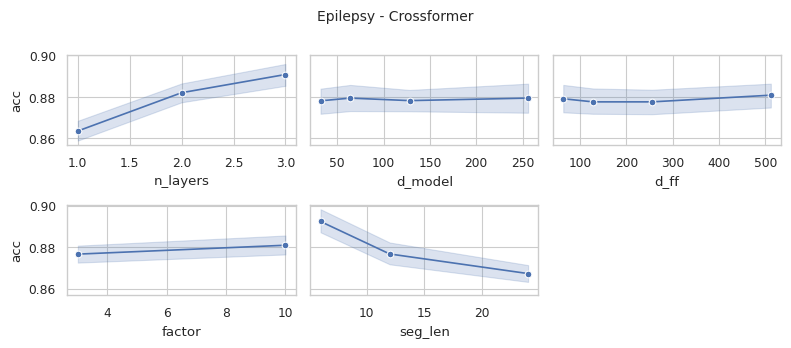

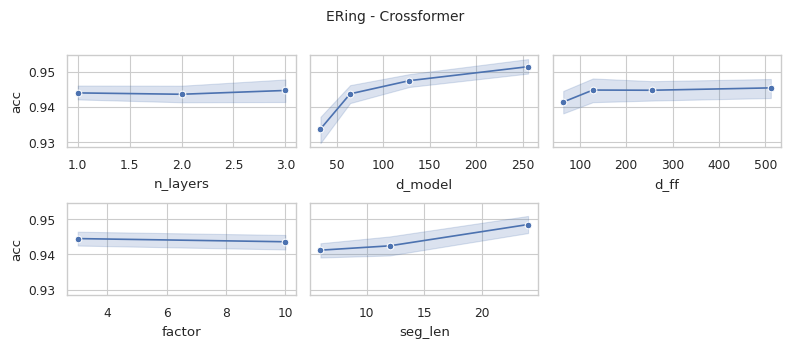

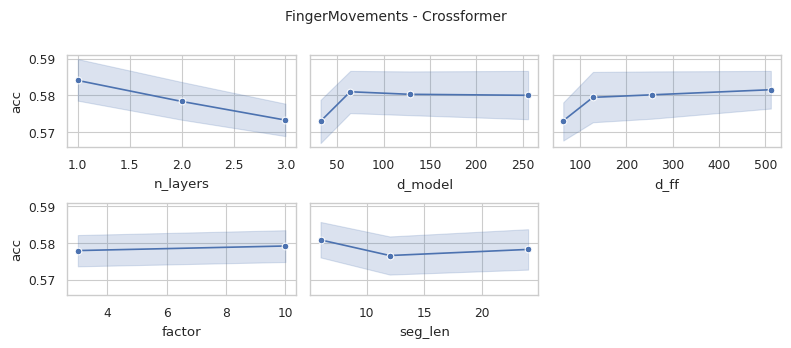

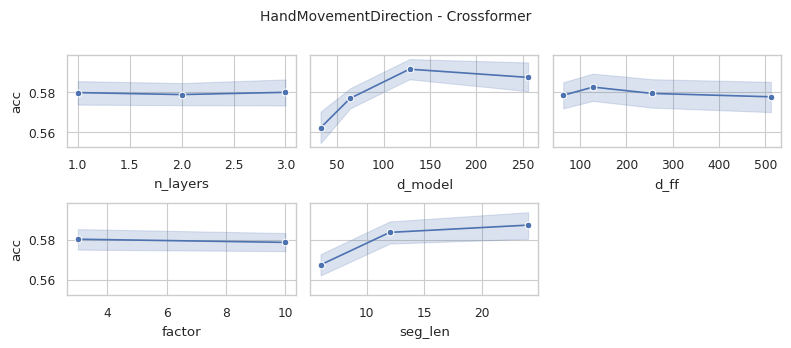

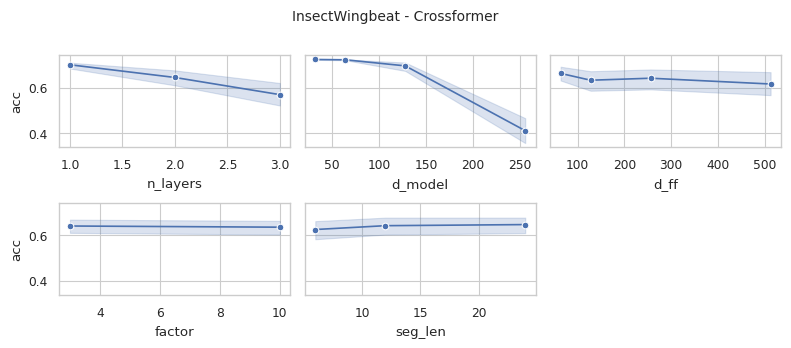

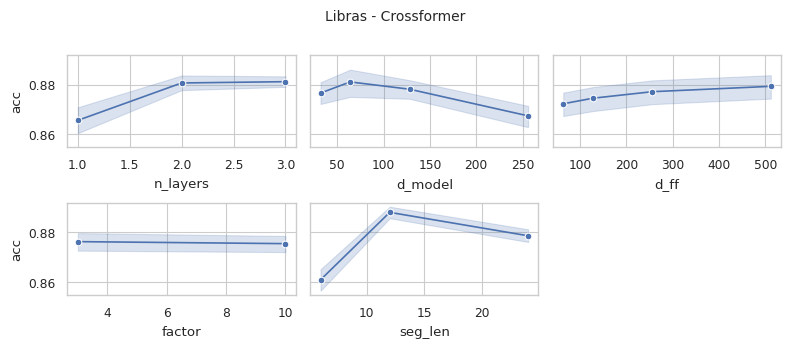

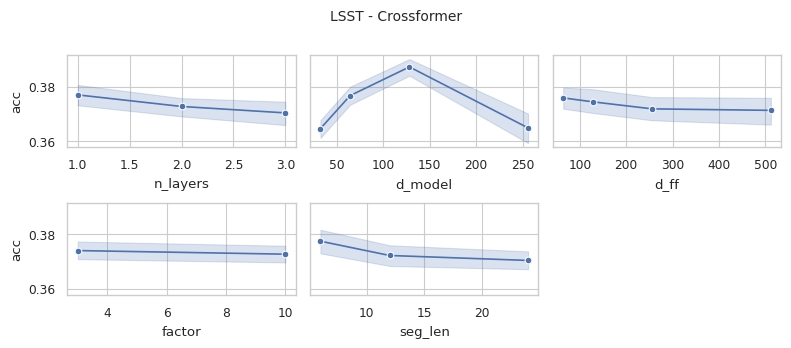

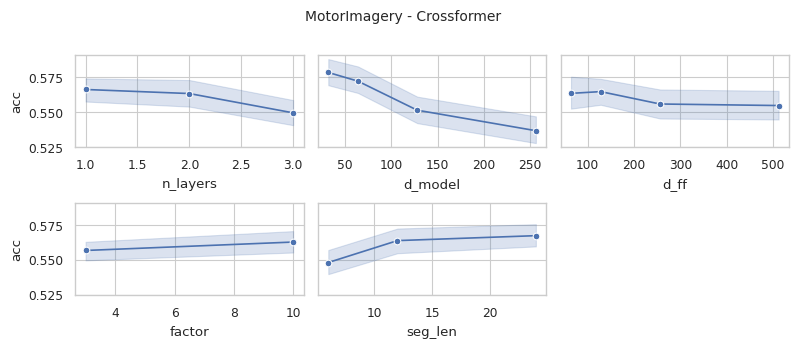

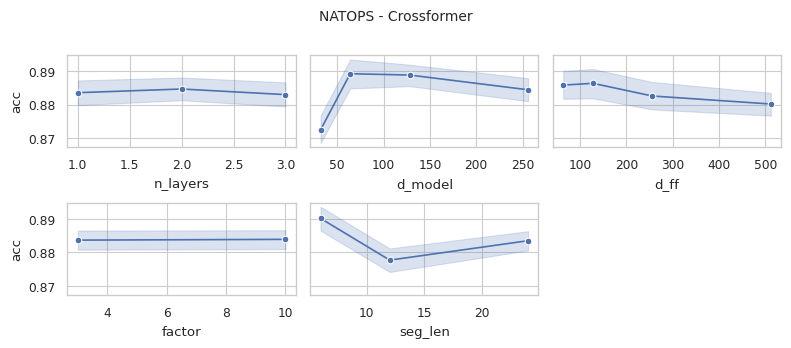

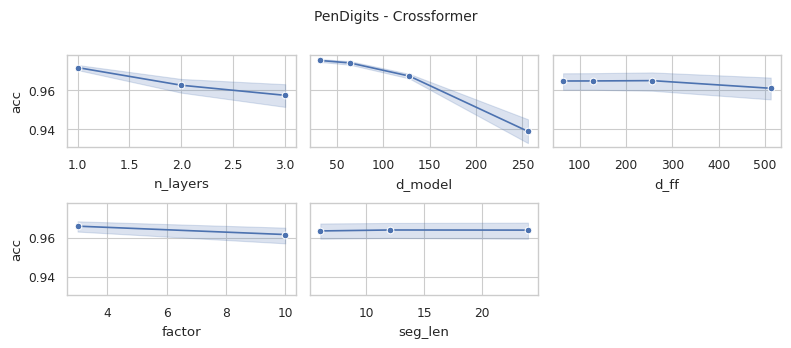

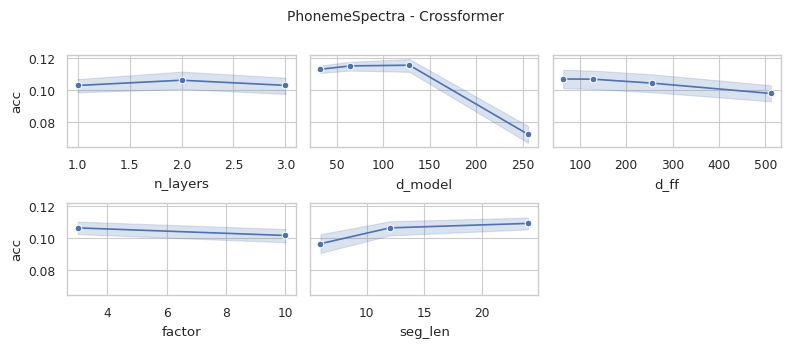

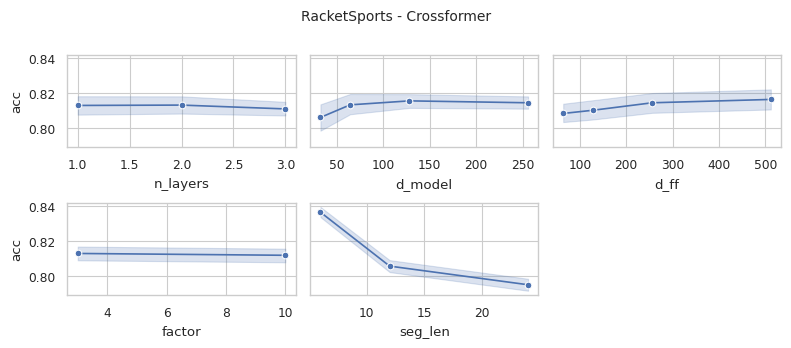

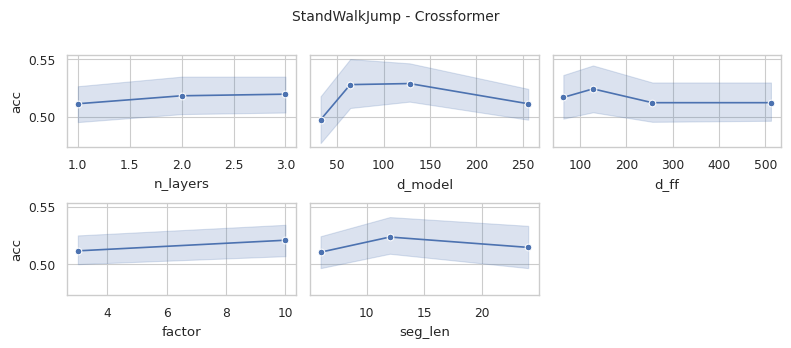

In [7]:
model = 'Crossformer'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            # dm256_nh8_el4_dl1_df512_expand2_dc4_fc4_ebtimeF_dtTrue_Exp_0
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('nh', ''))
            data_meta[12] = int(data_meta[12].replace('df', ''))
            data_meta[13] = int(data_meta[13].replace('fac', ''))
            data_meta[14] = int(data_meta[14].replace('seg', ''))


            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'n_heads': data_meta[11],
                'd_ff': data_meta[12],
                'factor': data_meta[13],
                'seg_len': data_meta[14],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_layers', 'd_model', 'd_ff', 'factor', 'seg_len']
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    for i in range(len(cols), num_cols*num_rows):
        fig.delaxes(axs[i//num_cols][i%num_cols])
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i//num_cols][i%num_cols].grid(False)
    #     axs[i//num_cols][i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    

In [9]:
model_configs = {
    "n_layers" : [1,2,3],
    "d_model" : [32,64,128,256],
    "d_ff" : [64,128,256,512],
    "factor" : [3,10],
    "seg_len_cf" : [6,12,24],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        n_layers = hyperparameter_combination['n_layers']
        d_model = hyperparameter_combination['d_model']
        d_ff = hyperparameter_combination['d_ff']
        factor = hyperparameter_combination['factor']
        seg_len = hyperparameter_combination['seg_len_cf']

        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['d_model'] == d_model)
                & (tmp['n_layers'] == n_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['d_ff'] == d_ff)
                & (tmp['factor'] == factor)
                & (tmp['seg_len'] == seg_len)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [10]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'n_layers': 3, 'd_model': 64, 'd_ff': 256, 'factor': 10, 'seg_len_cf': 12}","{'n_layers': 2, 'd_model': 128, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 24}","{'n_layers': 3, 'd_model': 64, 'd_ff': 64, 'factor': 3, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 64, 'd_ff': 128, 'factor': 3, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 64, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 6}","{'n_layers': 2, 'd_model': 128, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 64, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 12}","{'n_layers': 3, 'd_model': 64, 'd_ff': 64, 'factor': 10, 'seg_len_cf': 12}","{'n_layers': 2, 'd_model': 32, 'd_ff': 512, 'factor': 3, 'seg_len_cf': 12}",...,"{'n_layers': 2, 'd_model': 256, 'd_ff': 256, 'factor': 3, 'seg_len_cf': 12}","{'n_layers': 3, 'd_model': 256, 'd_ff': 256, 'factor': 10, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 256, 'd_ff': 256, 'factor': 10, 'seg_len_cf': 24}","{'n_layers': 3, 'd_model': 256, 'd_ff': 512, 'factor': 10, 'seg_len_cf': 12}","{'n_layers': 3, 'd_model': 256, 'd_ff': 128, 'factor': 3, 'seg_len_cf': 12}","{'n_layers': 3, 'd_model': 256, 'd_ff': 512, 'factor': 10, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 256, 'd_ff': 128, 'factor': 3, 'seg_len_cf': 24}","{'n_layers': 3, 'd_model': 256, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 24}","{'n_layers': 3, 'd_model': 256, 'd_ff': 128, 'factor': 10, 'seg_len_cf': 6}","{'n_layers': 3, 'd_model': 256, 'd_ff': 512, 'factor': 3, 'seg_len_cf': 6}"
EthanolConcentration,0.43346,0.395437,0.38403,0.346008,0.346008,0.334601,0.346008,0.311787,0.39924,0.429658,...,0.368821,0.311787,0.365019,0.353612,0.380228,0.353612,0.376426,0.380228,0.346008,0.326996
FaceDetection,0.696368,0.677072,0.676788,0.680193,0.683031,0.67622,0.668558,0.668842,0.681328,0.669977,...,0.549943,0.517026,0.5,0.54597,0.602724,0.650397,0.508513,0.536322,0.50681,0.5
Handwriting,0.303529,0.257647,0.268235,0.284706,0.298824,0.297647,0.282353,0.254118,0.264706,0.274118,...,0.269412,0.278824,0.275294,0.270588,0.285882,0.292941,0.271765,0.276471,0.282353,0.292941
Heartbeat,0.790244,0.770732,0.765854,0.770732,0.765854,0.765854,0.785366,0.760976,0.765854,0.760976,...,0.75122,0.741463,0.760976,0.765854,0.760976,0.760976,0.75122,0.746341,0.760976,0.746341
JapaneseVowels,0.983784,0.975676,0.972973,0.964865,0.964865,0.97027,0.97027,0.975676,0.972973,0.964865,...,0.97027,0.972973,0.967568,0.967568,0.962162,0.962162,0.972973,0.962162,0.956757,0.967568
PEMS-SF,0.895954,0.855491,0.849711,0.855491,0.867052,0.884393,0.843931,0.843931,0.855491,0.849711,...,0.895954,0.791908,0.820809,0.797688,0.849711,0.803468,0.861272,0.815029,0.83815,0.83815
SelfRegulationSCP1,0.938567,0.918089,0.904437,0.914676,0.924915,0.901024,0.904437,0.918089,0.918089,0.911263,...,0.887372,0.924915,0.90785,0.928328,0.897611,0.904437,0.90785,0.928328,0.928328,0.897611
SelfRegulationSCP2,0.616667,0.566667,0.538889,0.527778,0.577778,0.522222,0.511111,0.555556,0.55,0.527778,...,0.538889,0.561111,0.577778,0.527778,0.561111,0.522222,0.55,0.516667,0.516667,0.522222
SpokenArabicDigits,0.988631,0.974989,0.96271,0.976808,0.98181,0.975898,0.970896,0.9809,0.978172,0.98181,...,0.906321,0.88904,0.939973,0.938154,0.912688,0.764893,0.933606,0.946794,0.916326,0.914052
UWaveGestureLibrary,0.884375,0.865625,0.846875,0.846875,0.840625,0.846875,0.84375,0.846875,0.846875,0.825,...,0.840625,0.84375,0.865625,0.8625,0.85,0.846875,0.86875,0.859375,0.8375,0.83125


In [11]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'n_layers': 3, 'd_model': 64, 'd_ff': 256, 'factor': 10, 'seg_len_cf': 12}"
EthanolConcentration,43.34600760456274,39.54372623574145
FaceDetection,69.63677639046539,67.70715096481271
Handwriting,30.35294117647059,25.76470588235294
Heartbeat,79.02439024390245,77.07317073170732
JapaneseVowels,98.37837837837839,97.56756756756756
PEMS-SF,89.59537572254335,85.54913294797689
SelfRegulationSCP1,93.85665529010238,91.80887372013652
SelfRegulationSCP2,61.66666666666667,56.66666666666666
SpokenArabicDigits,98.86311959981809,97.49886311959982
UWaveGestureLibrary,88.4375,86.5625
